# Assignment 8

### Imports librarys

In [50]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("Import works")

Import works


I0000 00:00:1775225909.629699 5685349 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2


W0000 00:00:1775225909.771636 5722182 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775225909.802990 5722183 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Import video and plot frame

I0000 00:00:1775226927.299767 5685349 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1775226927.460091 5742602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775226927.486061 5742602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


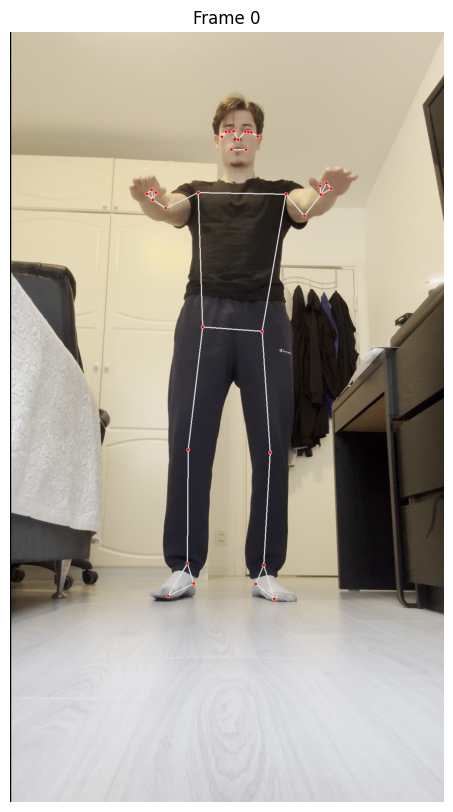

In [ ]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

mp_pose = mp.solutions.pose                 # gives pose model
mp_drawing = mp.solutions.drawing_utils     # helps draw skeleton

# Create a pose detector that works on video
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)





# Path
video_path = "../data/test_squat.mp4"

# Opens video file
cap = cv2.VideoCapture(video_path)

# read one frame (ret, true if succeeded)
ret, frame = cap.read()

# Rotate frame 
frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE) 

# Changes color chanels from BGR to RGB for MediaPipe
image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# MediaPipe analyzes image, detects human body, output keypoints
results = pose.process(image_rgb)

# Drea skeleton
mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

# Display resultat
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Frame 0")
plt.axis("off")

cap.release()


I0000 00:00:1775226885.516275 5685349 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1775226885.673001 5741881 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775226885.696945 5741883 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


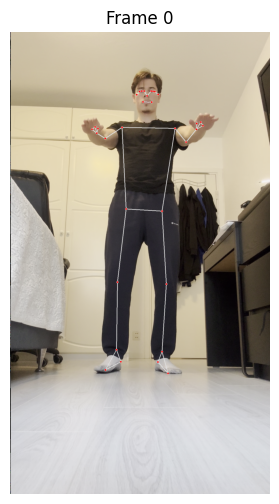

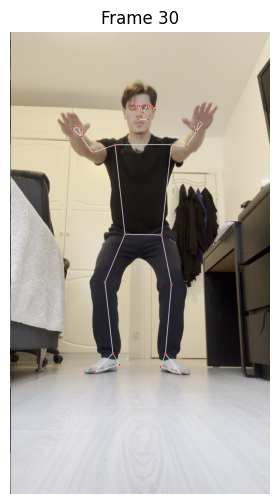

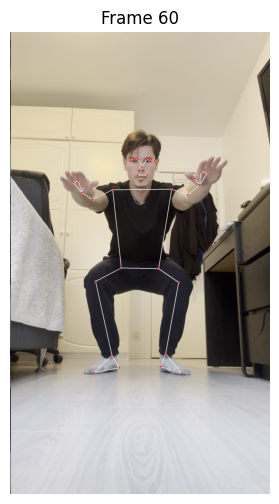

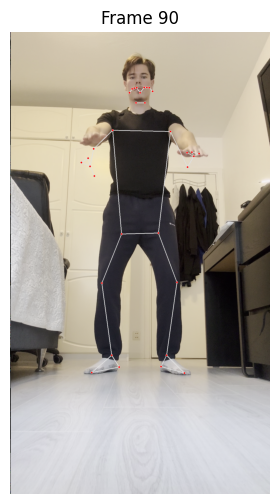

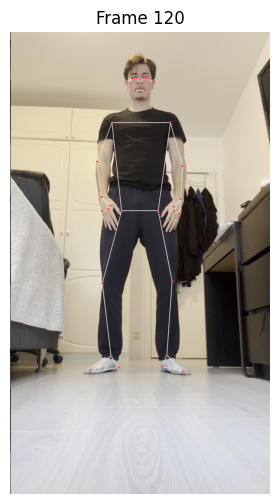

In [ ]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

mp_pose = mp.solutions.pose                 # gives pose model
mp_drawing = mp.solutions.drawing_utils     # helps draw skeleton

# Create a pose detector that works on video
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)




# Path
video_path = "../data/test_squat.mp4"

# Opens video file
cap = cv2.VideoCapture(video_path)

# Frame counter
frame_idx = 0

# Loop through the video
while cap.isOpened():

    # read one frame (ret, true if succeeded)
    ret, frame = cap.read()

    # Stop when video ends
    if not ret:
        break

    # Only processes evry 30th frame, 0 30 60...
    if frame_idx % 30 == 0:  

        # Rotate frame 
        frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE) 

        # Changes color chanels from BGR to RGB for MediaPipe
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # MediaPipe analyzes image, detects human body, output keypoints
        results = pose.process(image_rgb)

        # Drea skeleton
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        # Display result
        plt.figure(figsize=(4,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {frame_idx}")
        plt.axis("off")

    frame_idx += 1

cap.release()

In [ ]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

mp_pose = mp.solutions.pose                 # gives pose model
mp_drawing = mp.solutions.drawing_utils     # helps draw skeleton

# Create a pose detector that works on video
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)



# Paths
video_path = "../data/test_squat.mp4"
output_path = "../data/test_squat_keypoints.json"

# Opens video file
cap = cv2.VideoCapture(video_path)

# prepare to store keypoints for every frame
all_frames = []
frame_idx = 0

# Loop through the video
while cap.isOpened():

    # read one frame (ret, true if succeeded)
    ret, frame = cap.read()

    # Stop when video ends
    if not ret:
        break

    # Rotate video
    frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

    # Changes color chanels from BGR to RGB for MediaPipe
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # MediaPipe analyzes image, detects human body, output keypoints
    results = pose.process(image_rgb)

    # frame data structure
    frame_data = {
        "frame": frame_idx,
        "keypoints": []
    }

    # Extract keypoints if body detected
    if results.pose_landmarks:

        # Loop through landmarks (MediaPipe gives 33 keypoints)
        for i, lm in enumerate(results.pose_landmarks.landmark):

            # Save x and y cordinates
            frame_data["keypoints"].append({
                "id": i,
                "x": lm.x,
                "y": lm.y
            })
    
    # adds frame to dataset
    all_frames.append(frame_data)

    # increase frame counter
    frame_idx += 1

# clean up
cap.release()
pose.close()

# Save to JSON
with open(output_path, "w") as f:
    json.dump({
        "video_name": os.path.basename(video_path),
        "total_frames": frame_idx,
        "frames": all_frames
    }, f, indent=2)



I0000 00:00:1775227489.542988 5685349 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1775227489.720407 5752602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775227489.743907 5752602 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Done. Saved 144 frames to ../data/test_squat_keypoints.json
